In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


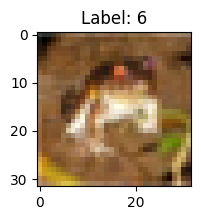

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Check dataset shape
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# Display the first image
plt.figure(figsize=(2,2))
plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0][0]}")
plt.show()


In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])


In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [10]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.3662 - loss: 1.7187 - val_accuracy: 0.5851 - val_loss: 1.1619
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6032 - loss: 1.1246 - val_accuracy: 0.6445 - val_loss: 1.0136
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.6640 - loss: 0.9601 - val_accuracy: 0.6831 - val_loss: 0.9180
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.7023 - loss: 0.8554 - val_accuracy: 0.6871 - val_loss: 0.8979
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.7271 - loss: 0.7793 - val_accuracy: 0.7007 - val_loss: 0.8744
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.7461 - loss: 0.7341 - val_accuracy: 0.7074 - val_loss: 0.8568
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7620 - loss: 0.6770 - val_accuracy: 0.7115 - val_loss: 0.8601
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.7770 -

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)


313/313 - 4s - 13ms/step - accuracy: 0.7002 - loss: 0.9229

Test accuracy: 0.7002000212669373


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


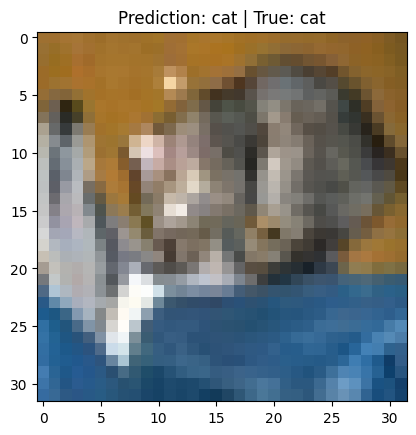

In [12]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test)

# Example: Predict first test image
plt.imshow(x_test[0])
plt.title(f"Prediction: {class_names[np.argmax(predictions[0])]} | True: {class_names[y_test[0][0]]}")
plt.show()
